# Etapa 2 -- Modelagem com Redes Neurais (MLP com PyTorch)

| Tarefa | Referencia |
|---|---|
| Construir MLP em PyTorch | Fundamentos, Aula 04 |
| Loop de treinamento com early stopping e batching | Fundamentos, Aula 04 |
| Comparar MLP vs. baselines usando >= 4 metricas | Fundamentos, Aula 05 |
| Analisar trade-off de custo (FP vs. FN) | Fundamentos, Aula 05 |
| Registrar experimentos no MLflow | Ciclo de Vida, Aula 02 |


## 1. Importacoes e Configuracao

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)
import mlflow, mlflow.sklearn, mlflow.pytorch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE} | PyTorch: {torch.__version__} | MLflow: {mlflow.__version__}')


Dispositivo: cpu | PyTorch: 2.11.0+cpu | MLflow: 3.11.1


## 2. Pre-processamento

In [2]:
df = pd.read_excel('../data/Telco_customer_churn.xlsx')
cols_drop = ['Count', 'Country', 'State', 'Lat Long', 'CustomerID']
df_clean = df.drop(columns=cols_drop)
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce').fillna(0)
df_clean['Churn'] = (df_clean['Churn Label'] == 'Yes').astype(int)
# Colunas com data leakage removidas
leak = ['Churn Label','Churn Reason','Churn Value','Churn Score','CLTV',
        'City','Zip Code','Latitude','Longitude']
X_raw = df_clean.drop(columns=[c for c in leak + ['Churn'] if c in df_clean.columns])
y = df_clean['Churn'].values
X_enc = pd.get_dummies(X_raw, drop_first=True)
print(f'Dataset: {X_enc.shape[0]} amostras | {X_enc.shape[1]} features | churn: {y.mean():.1%}')


Dataset: 7043 amostras | 30 features | churn: 26.5%


In [3]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_enc.values, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, random_state=SEED, stratify=y_trainval)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
print(f'Treino: {len(X_train_sc)} | Val: {len(X_val_sc)} | Teste: {len(X_test_sc)}')


Treino: 4932 | Val: 1054 | Teste: 1057


## 3. Arquitetura MLP

Input -> [Linear -> BatchNorm1d -> ReLU -> Dropout] x 3 -> Linear(1)


In [4]:
class ChurnMLP(nn.Module):
    """MLP para classificacao binaria de churn.
    Arquitetura: Input -> [Linear->BatchNorm->ReLU->Dropout] x N -> Linear(1)
    Saida: logit (sem sigmoid) -- use BCEWithLogitsLoss no treino.
    """
    def __init__(self, input_dim, hidden_dims, dropout=0.3):
        super().__init__()
        layers, in_dim = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

INPUT_DIM, HIDDEN, DROPOUT = X_train_sc.shape[1], [256, 128, 64], 0.3
model = ChurnMLP(INPUT_DIM, HIDDEN, DROPOUT).to(DEVICE)
print(model)
print(f'Parametros treinaveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


ChurnMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parametros treinaveis: 50,049


## 4. Treinamento com Early Stopping e Batching

In [5]:
def make_loader(X, y, batch_size=256, shuffle=True):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)


def train_mlp(model, train_loader, val_loader, lr=1e-3, epochs=150, patience=15, pos_weight_val=None):
    """
    Estrategia:
    - Otimizador: Adam + weight_decay=1e-4 (regularizacao L2)
    - Loss:       BCEWithLogitsLoss com pos_weight (desbalanceamento)
    - LR decay:   ReduceLROnPlateau (fator 0.5 apos 5 epochs sem melhora)
    - Early stop: restaura o melhor checkpoint apos patience epochs sem melhora
    """
    pw = torch.tensor([pos_weight_val], dtype=torch.float32).to(DEVICE) if pos_weight_val else None
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_val_loss, best_state, no_improve = float('inf'), None, 0

    for epoch in range(1, epochs + 1):
        model.train()
        tl = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward(); optimizer.step()
            tl += loss.item() * len(yb)
        tl /= len(train_loader.dataset)

        model.eval()
        vl, probs, labels = 0.0, [], []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits = model(Xb)
                vl += criterion(logits, yb).item() * len(yb)
                probs.extend(torch.sigmoid(logits).cpu().tolist())
                labels.extend(yb.cpu().tolist())
        vl /= len(val_loader.dataset)
        vf1 = f1_score(labels, (np.array(probs) >= 0.5).astype(int), zero_division=0)

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['val_f1'].append(vf1)
        scheduler.step(vl)

        if vl < best_val_loss - 1e-4:
            best_val_loss, best_state, no_improve = vl, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            no_improve += 1

        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d} | train={tl:.4f} | val={vl:.4f} | f1={vf1:.4f} | patience={no_improve}/{patience}')
        if no_improve >= patience:
            print(f'Early stopping epoch {epoch} (best val_loss={best_val_loss:.4f})')
            break

    if best_state:
        model.load_state_dict(best_state)
    print(f'Concluido. Melhor val_loss: {best_val_loss:.4f}')
    return history


In [6]:
BATCH_SIZE = 256
pos_weight_val = float((y_train == 0).sum() / (y_train == 1).sum())
print(f'pos_weight: {pos_weight_val:.2f}')
train_loader = make_loader(X_train_sc, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val_sc,   y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test_sc,  y_test,  BATCH_SIZE, shuffle=False)
history = train_mlp(model, train_loader, val_loader,
                    lr=1e-3, epochs=150, patience=15, pos_weight_val=pos_weight_val)


pos_weight: 2.77


Epoch  10 | train=0.6489 | val=0.7226 | f1=0.6019 | patience=2/15


Epoch  20 | train=0.6237 | val=0.7457 | f1=0.6147 | patience=12/15


Early stopping epoch 23 (best val_loss=0.7191)
Concluido. Melhor val_loss: 0.7191


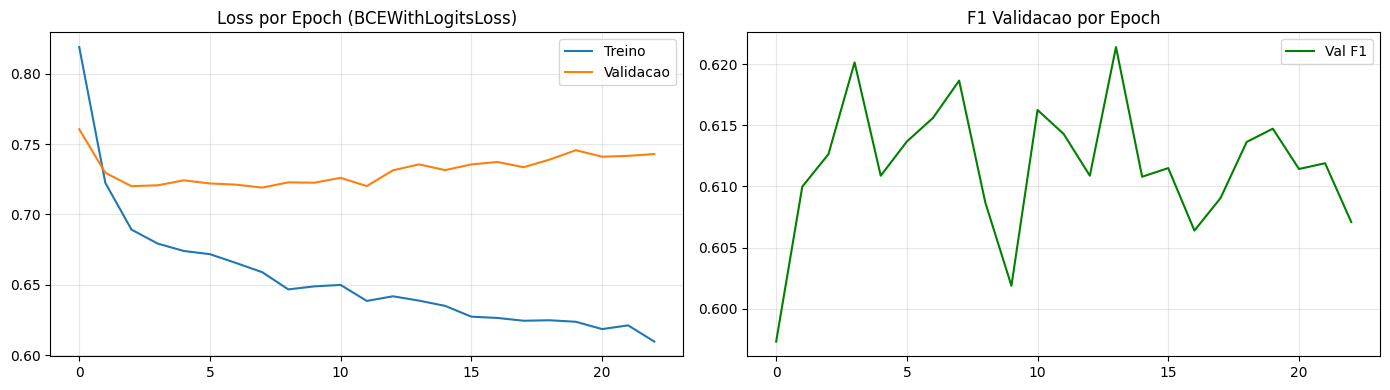

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'], label='Treino')
axes[0].plot(history['val_loss'],   label='Validacao')
axes[0].set_title('Loss por Epoch (BCEWithLogitsLoss)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history['val_f1'], color='green', label='Val F1')
axes[1].set_title('F1 Validacao por Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Modelos Baseline e Avaliacao

In [8]:
def evaluate(y_true, y_pred, y_prob=None):
    """6 metricas de classificacao binaria (>= 4 exigidas pelo Tech Challenge)."""
    m = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_prob is not None:
        m['auc_roc'] = roc_auc_score(y_true, y_prob)
        m['pr_auc']  = average_precision_score(y_true, y_prob)
    return m

X_tv_sc = scaler.transform(X_trainval)
baselines = {
    'Dummy':              DummyClassifier(strategy='most_frequent', random_state=SEED),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    'DecisionTree':       DecisionTreeClassifier(max_depth=6, random_state=SEED, class_weight='balanced'),
    'RandomForest':       RandomForestClassifier(n_estimators=200, max_depth=8, random_state=SEED,
                                                  class_weight='balanced', n_jobs=-1),
    'GradientBoosting':   GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                      learning_rate=0.05, random_state=SEED),
}
baseline_results = {}
for name, clf in baselines.items():
    clf.fit(X_tv_sc, y_trainval)
    yp    = clf.predict(X_test_sc)
    yprob = clf.predict_proba(X_test_sc)[:, 1] if hasattr(clf, 'predict_proba') else None
    baseline_results[name] = evaluate(y_test, yp, yprob)
    r = baseline_results[name]
    auc = f" | AUC={r['auc_roc']:.3f}" if 'auc_roc' in r else ''
    print(f"{name:22s}: F1={r['f1']:.3f} | Recall={r['recall']:.3f}{auc}")


Dummy                 : F1=0.000 | Recall=0.000 | AUC=0.500
LogisticRegression    : F1=0.631 | Recall=0.807 | AUC=0.857
DecisionTree          : F1=0.631 | Recall=0.839 | AUC=0.841


RandomForest          : F1=0.655 | Recall=0.814 | AUC=0.860


GradientBoosting      : F1=0.600 | Recall=0.546 | AUC=0.861


In [9]:
def predict_mlp(model, loader):
    model.eval(); probs, labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            probs.extend(torch.sigmoid(model(Xb.to(DEVICE))).cpu().tolist())
            labels.extend(yb.tolist())
    return np.array(labels), np.array(probs)

y_true, mlp_probs = predict_mlp(model, test_loader)
mlp_preds   = (mlp_probs >= 0.5).astype(int)
mlp_metrics = evaluate(y_true, mlp_preds, mlp_probs)
print('=== MLP (threshold=0.5) ===')
for k, v in mlp_metrics.items():
    print(f'  {k:12s}: {v:.4f}')
print()
print(classification_report(y_true, mlp_preds, target_names=['No Churn', 'Churn']))


=== MLP (threshold=0.5) ===
  accuracy    : 0.7465
  precision   : 0.5133
  recall      : 0.8286
  f1          : 0.6339
  auc_roc     : 0.8529
  pr_auc      : 0.6502

              precision    recall  f1-score   support

    No Churn       0.92      0.72      0.81       777
       Churn       0.51      0.83      0.63       280

    accuracy                           0.75      1057
   macro avg       0.72      0.77      0.72      1057
weighted avg       0.81      0.75      0.76      1057



## 6. Comparacao de Modelos com >= 4 Metricas

In [10]:
all_res = {**baseline_results, 'MLP (PyTorch)': mlp_metrics}
df_res  = pd.DataFrame(all_res).T[['accuracy','precision','recall','f1','auc_roc','pr_auc']]
df_res.columns = ['Accuracy','Precision','Recall','F1','AUC-ROC','PR-AUC']
print(df_res.round(4).to_string())


                    Accuracy  Precision  Recall      F1  AUC-ROC  PR-AUC
Dummy                 0.7351     0.0000  0.0000  0.0000   0.5000  0.2649
LogisticRegression    0.7502     0.5183  0.8071  0.6313   0.8566  0.6502
DecisionTree          0.7398     0.5054  0.8393  0.6309   0.8411  0.6198
RandomForest          0.7729     0.5481  0.8143  0.6552   0.8605  0.6732
GradientBoosting      0.8070     0.6652  0.5464  0.6000   0.8612  0.6737
MLP (PyTorch)         0.7465     0.5133  0.8286  0.6339   0.8529  0.6502


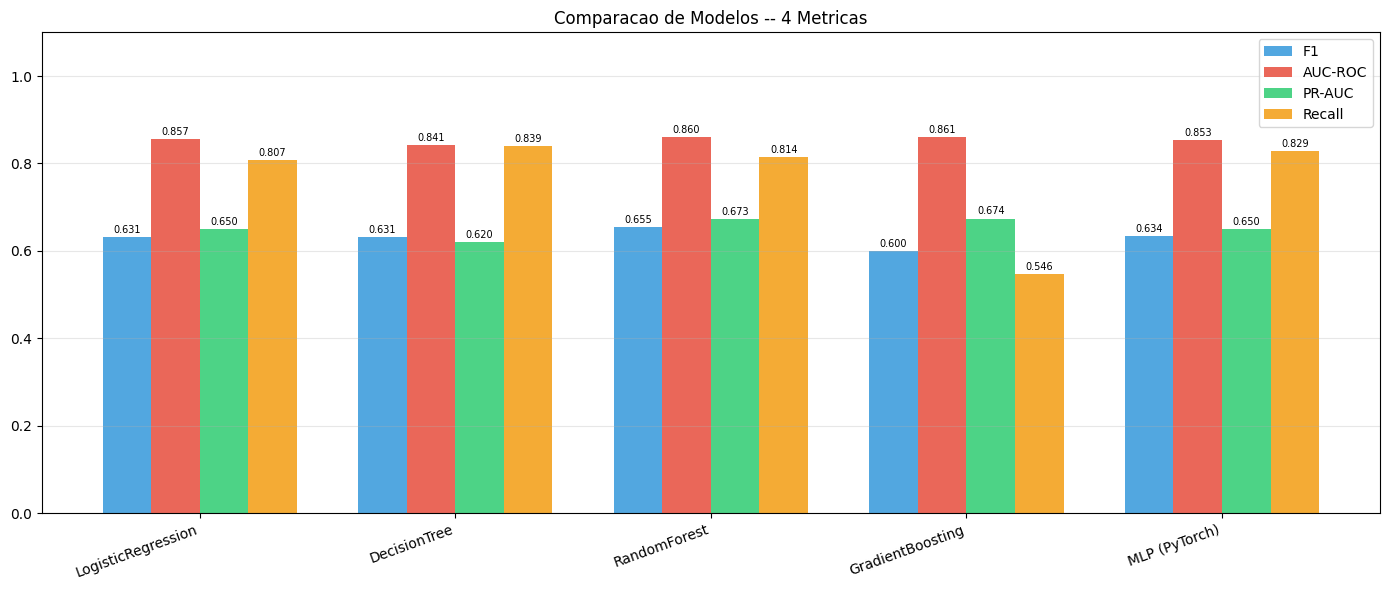

In [11]:
metrics_plot = ['F1', 'AUC-ROC', 'PR-AUC', 'Recall']
df_plot = df_res.drop('Dummy', errors='ignore')[metrics_plot]
x, width = np.arange(len(df_plot)), 0.19
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
fig, ax = plt.subplots(figsize=(14, 6))
for i, (col, color) in enumerate(zip(metrics_plot, colors)):
    bars = ax.bar(x + i*width, df_plot[col], width, label=col, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        if h == h:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.005, f'{h:.3f}',
                    ha='center', va='bottom', fontsize=7)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(df_plot.index, rotation=20, ha='right')
ax.set_ylim(0, 1.1); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('Comparacao de Modelos -- 4 Metricas')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


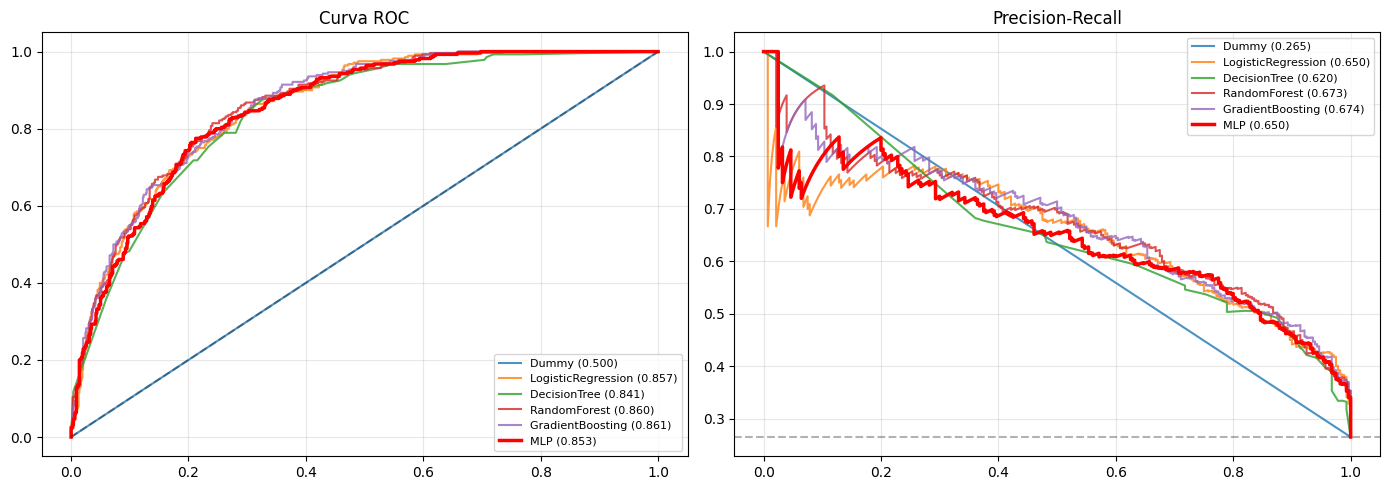

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, clf in baselines.items():
    if not hasattr(clf, 'predict_proba'):
        continue
    p = clf.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f'{name} ({roc_auc_score(y_test, p):.3f})', alpha=0.8)
    pr, rc, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rc, pr, label=f'{name} ({average_precision_score(y_test, p):.3f})', alpha=0.8)

fm, tm, _ = roc_curve(y_true, mlp_probs)
axes[0].plot(fm, tm, 'r-', lw=2.5, label=f"MLP ({mlp_metrics['auc_roc']:.3f})")
axes[0].plot([0,1],[0,1],'k--',alpha=0.3)
axes[0].set_title('Curva ROC'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

pm, rm, _ = precision_recall_curve(y_true, mlp_probs)
axes[1].plot(rm, pm, 'r-', lw=2.5, label=f"MLP ({mlp_metrics['pr_auc']:.3f})")
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.3)
axes[1].set_title('Precision-Recall'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Analise de Custo (FP vs. FN)

In [13]:
CLTV_MEDIO     = df_clean['CLTV'].mean()
CUSTO_RETENCAO = df_clean['Monthly Charges'].mean()
print(f'CLTV medio (custo FN):        R$ {CLTV_MEDIO:,.2f}')
print(f'Custo de retencao (custo FP): R$ {CUSTO_RETENCAO:,.2f}')
print(f'Razao FN/FP: {CLTV_MEDIO/CUSTO_RETENCAO:.1f}x')


CLTV medio (custo FN):        R$ 4,400.30
Custo de retencao (custo FP): R$ 64.76
Razao FN/FP: 67.9x


In [14]:
thresholds = np.linspace(0.05, 0.95, 100)
costs, fps, fns = [], [], []
for t in thresholds:
    preds = (mlp_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    costs.append(fp * CUSTO_RETENCAO + fn * CLTV_MEDIO)
    fps.append(int(fp)); fns.append(int(fn))

best_idx    = int(np.argmin(costs))
best_thresh = float(thresholds[best_idx])
best_cost   = costs[best_idx]

preds_05 = (mlp_probs >= 0.5).astype(int)
tn05, fp05, fn05, tp05 = confusion_matrix(y_true, preds_05).ravel()
cost_05 = float(fp05) * CUSTO_RETENCAO + float(fn05) * CLTV_MEDIO
fp_05, fn_05 = int(fp05), int(fn05)

print(f'Threshold otimo: {best_thresh:.2f} | Custo: R$ {best_cost:,.2f} (FP={fps[best_idx]}, FN={fns[best_idx]})')
print(f'Threshold=0.50:  custo: R$ {cost_05:,.2f} (FP={fp_05}, FN={fn_05})')
print(f'Economia: R$ {cost_05-best_cost:,.2f} ({(cost_05-best_cost)/cost_05:.1%})')


Threshold otimo: 0.06 | Custo: R$ 36,590.36 (FP=565, FN=0)
Threshold=0.50:  custo: R$ 225,461.77 (FP=220, FN=48)
Economia: R$ 188,871.41 (83.8%)


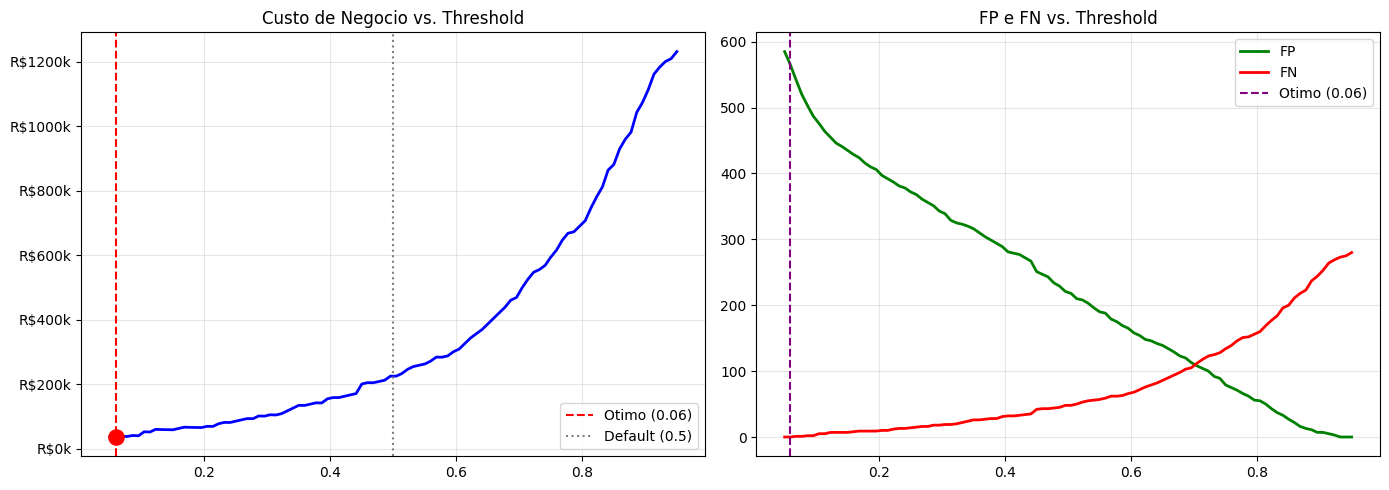

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thresholds, costs, 'b-', lw=2)
axes[0].axvline(best_thresh, color='r', linestyle='--', label=f'Otimo ({best_thresh:.2f})')
axes[0].axvline(0.5, color='gray', linestyle=':', label='Default (0.5)')
axes[0].scatter([best_thresh], [best_cost], color='red', s=120, zorder=5)
axes[0].set_title('Custo de Negocio vs. Threshold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'R${x/1000:.0f}k'))

axes[1].plot(thresholds, fps, 'g-', lw=2, label='FP')
axes[1].plot(thresholds, fns, 'r-', lw=2, label='FN')
axes[1].axvline(best_thresh, color='purple', linestyle='--', label=f'Otimo ({best_thresh:.2f})')
axes[1].set_title('FP e FN vs. Threshold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cost_analysis.png', dpi=100, bbox_inches='tight')
plt.show()


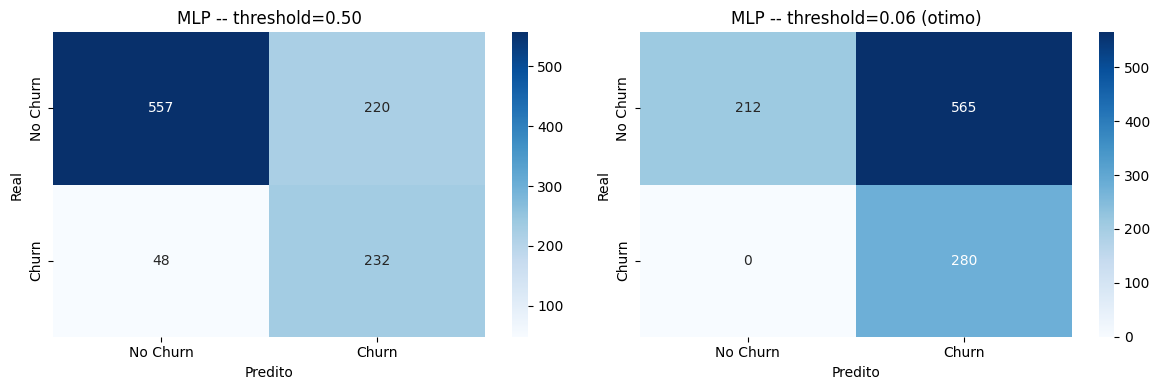

thresh=0.50:           F1=0.6339 | Recall=0.8286
thresh=0.06 (otimo): F1=0.4978 | Recall=1.0000


In [16]:
mlp_preds_opt   = (mlp_probs >= best_thresh).astype(int)
mlp_metrics_opt = evaluate(y_true, mlp_preds_opt, mlp_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (preds, title) in zip(axes, [
    (mlp_preds,     'MLP -- threshold=0.50'),
    (mlp_preds_opt, f'MLP -- threshold={best_thresh:.2f} (otimo)'),
]):
    sns.heatmap(confusion_matrix(y_true, preds), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_title(title); ax.set_ylabel('Real'); ax.set_xlabel('Predito')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'thresh=0.50:           F1={mlp_metrics["f1"]:.4f} | Recall={mlp_metrics["recall"]:.4f}')
print(f'thresh={best_thresh:.2f} (otimo): F1={mlp_metrics_opt["f1"]:.4f} | Recall={mlp_metrics_opt["recall"]:.4f}')


## 8. MLflow -- Servidor Local (http://localhost:5000)

In [17]:
MLFLOW_URI = "http://localhost:5000"
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("Tech_Challenge_4_Churn")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

BASELINE_PARAMS = {
    'Dummy':              {'strategy': 'most_frequent'},
    'LogisticRegression': {'max_iter': 1000, 'class_weight': 'balanced'},
    'DecisionTree':       {'max_depth': 6, 'class_weight': 'balanced'},
    'RandomForest':       {'n_estimators': 200, 'max_depth': 8, 'class_weight': 'balanced'},
    'GradientBoosting':   {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05},
}
for name, clf in baselines.items():
    with mlflow.start_run(run_name=f"Etapa2_{name}"):
        mlflow.log_params({'model_type': name, 'etapa': 2, **BASELINE_PARAMS.get(name, {})})
        mlflow.log_metrics({k: round(float(v), 4) for k, v in baseline_results[name].items()})
        mlflow.sklearn.log_model(clf, 'model')
        print(f"[MLflow] {name:22s} | F1={baseline_results[name]['f1']:.4f}")
print("Baselines registrados.")


Tracking URI: http://localhost:5000


2026/04/13 23:00:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/13 23:00:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[MLflow] Dummy                  | F1=0.0000
🏃 View run Etapa2_Dummy at: http://localhost:5000/#/experiments/1/runs/fdc031be3b7445d784d067cf6fdbafd8
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/04/13 23:00:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

2026/04/13 23:00:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[MLflow] RandomForest           | F1=0.6552
🏃 View run Etapa2_RandomForest at: http://localhost:5000/#/experiments/1/runs/8e91bb7f65e14253aae86c43da01d529
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/04/13 23:00:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/13 23:00:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[MLflow] GradientBoosting       | F1=0.6000
🏃 View run Etapa2_GradientBoosting at: http://localhost:5000/#/experiments/1/runs/2dea567e80ee4eec9f1fcf32c1e85a31
🧪 View experiment at: http://localhost:5000/#/experiments/1
Baselines registrados.


In [18]:
with mlflow.start_run(run_name="Etapa2_MLP_PyTorch"):
    mlflow.log_params({
        'model_type':   'MLP_PyTorch', 'etapa': 2,
        'input_dim':    INPUT_DIM, 'hidden_dims': str(HIDDEN), 'dropout': DROPOUT,
        'batch_size':   BATCH_SIZE, 'optimizer': 'Adam', 'lr': 1e-3, 'weight_decay': 1e-4,
        'loss_fn':      'BCEWithLogitsLoss', 'pos_weight': round(pos_weight_val, 3),
        'patience':     15, 'epochs_trained': len(history['train_loss']), 'device': str(DEVICE),
    })
    mlflow.log_metrics({k: round(float(v), 4) for k, v in mlp_metrics.items()})
    mlflow.log_metrics({
        'optimal_threshold': round(best_thresh, 4),
        'optimal_f1':        round(float(mlp_metrics_opt['f1']), 4),
        'optimal_recall':    round(float(mlp_metrics_opt['recall']), 4),
        'business_cost_opt': round(float(best_cost), 2),
        'business_cost_def': round(float(cost_05), 2),
        'cost_saving':       round(float(cost_05 - best_cost), 2),
    })
    for art in ['learning_curves.png','model_comparison.png',
                'roc_pr_curves.png','cost_analysis.png','confusion_matrix.png']:
        mlflow.log_artifact(art)
    mlflow.pytorch.log_model(model, 'mlp_model')
    print(f"[MLflow] MLP registrado em http://localhost:5000")
    print(f"  F1={mlp_metrics['f1']:.4f} | AUC={mlp_metrics['auc_roc']:.4f} | Recall={mlp_metrics['recall']:.4f}")
    print(f"  Threshold otimo={best_thresh:.2f} | Economia=R${cost_05-best_cost:,.2f}")


2026/04/13 23:00:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/13 23:00:46 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


2026/04/13 23:00:46 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


2026/04/13 23:00:50 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[MLflow] MLP registrado em http://localhost:5000
  F1=0.6339 | AUC=0.8529 | Recall=0.8286
  Threshold otimo=0.06 | Economia=R$188,871.41
🏃 View run Etapa2_MLP_PyTorch at: http://localhost:5000/#/experiments/1/runs/5f11519195ef44a7815e743957d3aac4
🧪 View experiment at: http://localhost:5000/#/experiments/1


## 9. Resumo Final

In [19]:
df_final = df_res.copy()
df_final.loc[f'MLP (thresh={best_thresh:.2f})'] = [
    mlp_metrics_opt['accuracy'], mlp_metrics_opt['precision'],
    mlp_metrics_opt['recall'],   mlp_metrics_opt['f1'],
    mlp_metrics_opt['auc_roc'],  mlp_metrics_opt['pr_auc'],
]
print('=== TABELA FINAL ===')
print(df_final.round(4).to_string())


=== TABELA FINAL ===
                    Accuracy  Precision  Recall      F1  AUC-ROC  PR-AUC
Dummy                 0.7351     0.0000  0.0000  0.0000   0.5000  0.2649
LogisticRegression    0.7502     0.5183  0.8071  0.6313   0.8566  0.6502
DecisionTree          0.7398     0.5054  0.8393  0.6309   0.8411  0.6198
RandomForest          0.7729     0.5481  0.8143  0.6552   0.8605  0.6732
GradientBoosting      0.8070     0.6652  0.5464  0.6000   0.8612  0.6737
MLP (PyTorch)         0.7465     0.5133  0.8286  0.6339   0.8529  0.6502
MLP (thresh=0.06)     0.4655     0.3314  1.0000  0.4978   0.8529  0.6502
